# Experimental Evaluation

In [1]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

## Change here time limit for the benchmark. Do not modify this variable below.
MAX_TIME = 600.00

font = {
        'size'   : 11}
mpl.rc('font', **font)

## Helper functions

In [2]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


In [4]:
def set_square_size(width_pt, fraction=1):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    return (fig_width_in, fig_width_in)

In [5]:
def csv_info(table, verdict_str, time_str):
    print("Number of instances:", table.shape[0])
    print("SAT:", table.query(verdict_str + " == 'sat'").shape[0])
    print("UNSAT:", table.query(verdict_str + " == 'unsat'").shape[0])
    print("SAT or UNSAT:", table.query(verdict_str + " == 'sat' or " + verdict_str + " == 'unsat'").shape[0])
    print("UNKNOWN:", table.query(verdict_str + " == 'unknown'").shape[0])
    print("TIMEOUT:", table.query(verdict_str + " == 'timeout'").shape[0])
    count_errors = table[table[verdict_str].str.contains("error:", na=False)].shape[0]
    print("ERROR:", count_errors)

In [6]:
def plot_survival(table, solvers, verdict_types, labels, colors, y_text, plot_name):
    solver_times_sorted = {}
    solver_cumulative_sol = {}
    solver_plot = {}
    
    plt.figure(figsize=(8,6))
    
    for solver in solvers:
        verdict_col = f'verdict_{solver}'
        time_col = f'time_{solver}'
        
        times = table.loc[table[verdict_col].isin(verdict_types), time_col]
        times = pd.to_numeric(times, errors='coerce').dropna()
    
        solver_times_sorted[solver] = np.sort(times)
        solver_cumulative_sol[solver] = np.arange(1, len(solver_times_sorted[solver])+1)
    
        solver_plot[solver] = np.clip(solver_times_sorted[solver], min_time, None)
        solver_plot[solver] = np.append(solver_plot[solver], max_time)
        solver_cumulative_sol[solver] = np.append(solver_cumulative_sol[solver], solver_cumulative_sol[solver][-1])
    
        plt.step(solver_plot[solver], solver_cumulative_sol[solver], where='post', color = colors[solver], label=labels[solver])
    
    plt.xlabel('Time (seconds)')
    plt.ylabel(y_text)
    plt.legend()
    plt.grid(True, which='both')
    
    plt.xscale('log', base=10)
    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    plt.xticks([min_time*(10**i) for i in range(int(np.log10(max_time))+2)])
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [7]:
def plot_scatter_solvers(table, solvers, verdict_types, labels, colors, plot_name, min_time=None, max_time=None, category_col=None, category_colors=None, category_labels=None, logscale=True, x_label=None, y_label=None):
    """
    Create a scatter plot comparing the runtime of two solvers.
    """
    
    # Ensure we have exactly 2 solvers
    if len(solvers) != 2:
        raise ValueError("This function expects exactly 2 solvers")
        
    solver1, solver2 = solvers[0], solvers[1]
    verdict_col1 = f'verdict_{solver1}'
    time_col1 = f'time_{solver1}'
    verdict_col2 = f'verdict_{solver2}'
    time_col2 = f'time_{solver2}'
    
    # Filter for instances solved by both solvers with the specified verdicts
    mask1 = table[verdict_col1].isin(verdict_types)
    mask2 = table[verdict_col2].isin(verdict_types)
    mask = mask1 & mask2
    
    times1 = pd.to_numeric(table.loc[mask, time_col1], errors='coerce')
    times2 = pd.to_numeric(table.loc[mask, time_col2], errors='coerce')
    
    # Drop NaN values
    valid_mask = times1.notna() & times2.notna()
    times1 = times1[valid_mask]
    times2 = times2[valid_mask]
    
    # Keep track of categories if provided
    if category_col is not None:
        categories_data = table.loc[mask, category_col][valid_mask]
    
    times1_vals = times1.values
    times2_vals = times2.values
    
    # Set axis limits if not provided
    if min_time is None:
        min_time = min(np.min(times1_vals), np.min(times2_vals)) * 0.9
    if max_time is None:
        max_time = max(np.max(times1_vals), np.max(times2_vals)) * 1.1
    
    fig, ax = plt.subplots(figsize=(8, 8)) # Swapped to object-oriented style to handle formatters easily
    
    # Plot scatter points
    if category_col is not None:
        # Plot by categories
        categories = categories_data.values
        for category in sorted(set(categories)):
            cat_mask = categories == category
            color = category_colors.get(category, 'gray')
            if category_labels is not None:
                label = category_labels.get(category, str(category))
                ax.scatter(times1_vals[cat_mask], times2_vals[cat_mask], color=color, alpha=0.6, s=50, label=label)
            else:
                ax.scatter(times1_vals[cat_mask], times2_vals[cat_mask], color=color, alpha=0.6, s=50)
        if category_labels is not None: ax.legend()
    else:
        # Plot all points with same color
        ax.scatter(times1_vals, times2_vals, color=colors[solver1], alpha=0.6, s=50)
    
    # Add diagonal reference line (y=x)
    diag_min = min(min_time, min_time)
    diag_max = max(max_time, max_time)
    ax.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.4, linewidth=1)
    
    if x_label is not None : ax.set_xlabel(x_label, fontsize=32)
    if y_label is not None: ax.set_ylabel(y_label, fontsize=32)
    ax.grid(True, which='both', alpha=0.3)

    ax.tick_params(axis='both', labelsize=18)
    
    # Handle Scales and Number Formatting
    if logscale:
        ax.set_xscale('log', base=10)
        ax.set_yscale('log', base=10)
        
        # Force clean, dynamic float formatting (prevents 0.1 from turning into 0)
        from matplotlib.ticker import FuncFormatter
        plain_formatter = FuncFormatter(lambda y, _: f'{y:g}')
        
        ax.xaxis.set_major_formatter(plain_formatter)
        ax.yaxis.set_major_formatter(plain_formatter)
    else:
        # Force plain text labels if it defaults to scientific notation on standard scales
        ax.ticklabel_format(style='plain', useOffset=False, axis='both')
        
    # Set axis limits
    ax.set_xlim(min_time, max_time)
    ax.set_ylim(min_time, max_time)
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [8]:
# Table cleaner 
def clean(table, solvers): 
    for solver in solvers: 
        verdict = f'verdict_{solver}'
        time    = f'time_{solver}'
        table.loc[table[verdict].isna(), verdict] = "timeout"
        table.loc[table[time].isna(), time] = MAX_TIME
        table.loc[table[verdict] == 'unknown', time] = MAX_TIME
        table.loc[table[verdict] == 'unknown', verdict] = "timeout"
        

# Benchmark: Split 2-20 - Existence problem

### Instances

In [9]:
solvers_2 = ["sym_2_20","par_2_20"]

# Category: Modular

par_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-par.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-sym.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Modular tables:", par_2_20_modular.shape[0], sym_2_20_modular.shape[0])

modular_2_20 = pd.merge(par_2_20_modular, sym_2_20_modular, on="instance", how="outer")
clean(modular_2_20, solvers_2)
modular_2_20['category'] = "modular"

# Category: Random (Existence)

par_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Random tables:", par_2_20_random_e.shape[0], sym_2_20_random_e.shape[0])

random_2_20_e = pd.merge(par_2_20_random_e, sym_2_20_random_e, on="instance", how="outer")
clean(random_2_20_e, solvers_2)
random_2_20_e['category'] = "random_e"

# Category: Mixed (Existence)

par_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Mixed tables:", par_2_20_mixed_e.shape[0], sym_2_20_mixed_e.shape[0])

mixed_2_20_e = pd.merge(par_2_20_mixed_e, sym_2_20_mixed_e, on="instance", how="outer")
clean(mixed_2_20_e, solvers_2)
mixed_2_20_e['category'] = "random_e"

# Combine Tables 

table_2_20 = pd.concat([modular_2_20, random_2_20_e, mixed_2_20_e], ignore_index=True)
table_2_20

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_2_20,time_par_2_20,verdict_sym_2_20,time_sym_2_20,category
0,ai-instances/modular/modular_01.smt2,unsat,0.21,unsat,0.23,modular
1,ai-instances/modular/modular_02.smt2,unsat,1.52,unsat,2.83,modular
2,ai-instances/modular/modular_03.smt2,sat,2.32,sat,3.96,modular
3,ai-instances/modular/modular_04.smt2,sat,0.48,sat,0.64,modular
4,ai-instances/modular/modular_05.smt2,sat,2.29,sat,4.01,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,378.09,unsat,62.52,random_e
86,ai-instances/random-mixed/mixed_27.smt2,sat,3.22,sat,0.86,random_e
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.06,sat,0.05,random_e
88,ai-instances/random-mixed/mixed_29.smt2,sat,10.48,sat,9.33,random_e


### Scatter plot

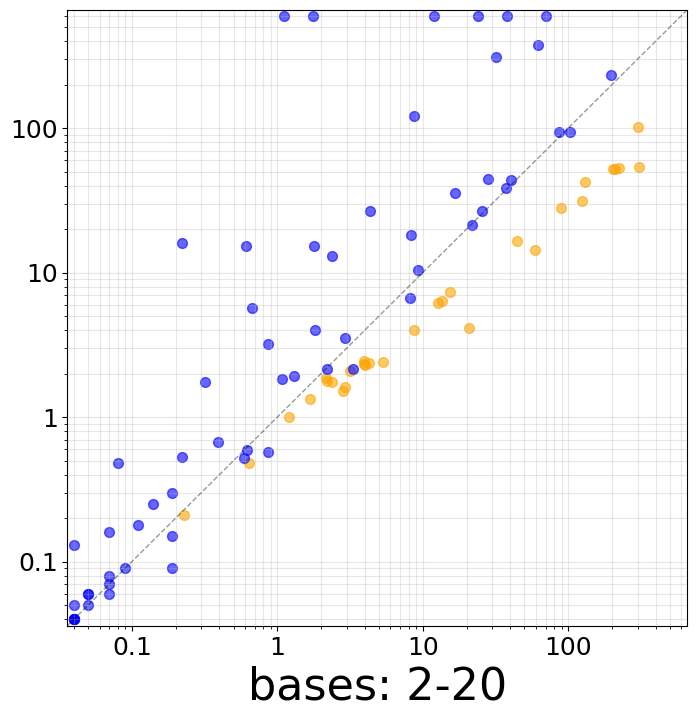

In [10]:
plot_scatter_solvers(
    table =  table_2_20,
    solvers= solvers_2,
    verdict_types= ['sat', 'unsat', 'timeout'],
    labels = {'sym_2_20': 'Sym', 'par_2_20': 'Par'},
    colors = {'sym_2_20': 'blue', 'par_2_20': 'red'},  # ignored when using categories
    plot_name = 'scatter-2-20-existence.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'modular': 'orange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 2-20"
)

# Benchmark: Split 21-200 - Existence problem

### Instances

In [11]:
solvers_21 = ["sym_21_200","par_21_200"]

# Category: Modular

par_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-par.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-sym.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Modular tables:", par_21_200_modular.shape[0], sym_21_200_modular.shape[0])

modular_21_200 = pd.merge(par_21_200_modular, sym_21_200_modular, on="instance", how="outer")
clean(modular_21_200, solvers_21)
modular_21_200['category'] = "modular"

# Category: Random (Existence)

par_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Random tables:", par_21_200_random_e.shape[0], sym_21_200_random_e.shape[0])

random_21_200_e = pd.merge(par_21_200_random_e, sym_21_200_random_e, on="instance", how="outer")
clean(random_21_200_e, solvers_21)
random_21_200_e['category'] = "random_e"

# Category: Mixed (Existence)

par_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Mixed tables:", par_21_200_mixed_e.shape[0], sym_21_200_mixed_e.shape[0])

mixed_21_200_e = pd.merge(par_21_200_mixed_e, sym_21_200_mixed_e, on="instance", how="outer")
clean(mixed_21_200_e, solvers_21)
mixed_21_200_e['category'] = "random_e"

# Combine Tables 

table_21_200 = pd.concat([modular_21_200, 
                          random_21_200_e, 
                          # mixed_21_200_e
                         ], ignore_index=True)
table_21_200

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_21_200,time_par_21_200,verdict_sym_21_200,time_sym_21_200,category
0,ai-instances/modular/modular_01.smt2,unsat,1.83,unsat,2.14,modular
1,ai-instances/modular/modular_02.smt2,sat,0.39,sat,0.72,modular
2,ai-instances/modular/modular_03.smt2,sat,4.51,sat,8.02,modular
3,ai-instances/modular/modular_04.smt2,sat,0.42,sat,0.53,modular
4,ai-instances/modular/modular_05.smt2,sat,4.45,sat,8.18,modular
5,ai-instances/modular/modular_06.smt2,sat,2.38,sat,5.47,modular
6,ai-instances/modular/modular_07.smt2,sat,0.45,sat,0.79,modular
7,ai-instances/modular/modular_08.smt2,unsat,72.97,unsat,158.56,modular
8,ai-instances/modular/modular_09.smt2,unsat,240.92,unsat,517.90,modular
9,ai-instances/modular/modular_10.smt2,unsat,54.41,unsat,105.28,modular


### Scatter Plot

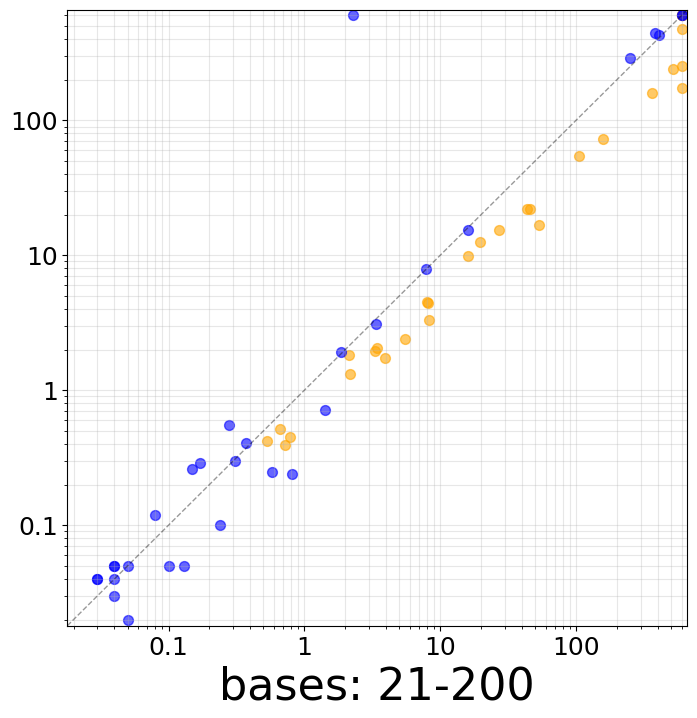

In [12]:
plot_scatter_solvers(
    table = table_21_200,
    solvers= solvers_21,
    verdict_types = ['sat', 'unsat', 'timeout'],
    labels = {'sym_21_200': 'Sym', 'par_21_200': 'Par'},
    colors = {'sym_21_200': 'blue', 'par_21_200': 'red'},  # ignored when using categories
    plot_name = 'scatter-21-200-existence.pgf',
    category_col = 'category',                         # column with categories
    category_colors = {
        'modular': 'orange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 21-200"
)

# Benchmark: Split 201-220 - Existence problem

### Instances

In [13]:
solvers_201 = ["par_201_220","sym_201_220"]

# Category: Modular

par_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-par.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-sym.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Modular tables:", par_201_220_modular.shape[0], sym_201_220_modular.shape[0])

modular_201_220 = pd.merge(par_201_220_modular, sym_201_220_modular, on="instance", how="outer")
clean(modular_201_220, solvers_201)
modular_201_220['category'] = "modular"

# Category: Random (Existence)

par_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Random tables:", par_201_220_random_e.shape[0], sym_201_220_random_e.shape[0])

random_201_220_e = pd.merge(par_201_220_random_e, sym_201_220_random_e, on="instance", how="outer")
clean(random_201_220_e, solvers_201)
random_201_220_e['category'] = "random_e"

# Category: Mixed (Existence)

par_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Mixed tables:", par_201_220_mixed_e.shape[0], sym_201_220_mixed_e.shape[0])

mixed_201_220_e = pd.merge(par_201_220_mixed_e, sym_201_220_mixed_e, on="instance", how="outer")
clean(mixed_201_220_e, solvers_201)
mixed_201_220_e['category'] = "random_e"

# Combine Tables 

table_201_220 = pd.concat([modular_201_220, random_201_220_e, mixed_201_220_e], ignore_index=True)
table_201_220

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_201_220,time_par_201_220,verdict_sym_201_220,time_sym_201_220,category
0,ai-instances/modular/modular_01.smt2,unsat,0.25,unsat,0.25,modular
1,ai-instances/modular/modular_02.smt2,sat,0.38,sat,0.77,modular
2,ai-instances/modular/modular_03.smt2,sat,4.02,sat,6.47,modular
3,ai-instances/modular/modular_04.smt2,sat,0.29,sat,0.54,modular
4,ai-instances/modular/modular_05.smt2,sat,4.80,sat,6.63,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,32.74,unsat,55.96,random_e
86,ai-instances/random-mixed/mixed_27.smt2,sat,3.51,sat,0.61,random_e
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.04,sat,0.03,random_e
88,ai-instances/random-mixed/mixed_29.smt2,sat,2.46,sat,2.51,random_e


### Scatter Plot

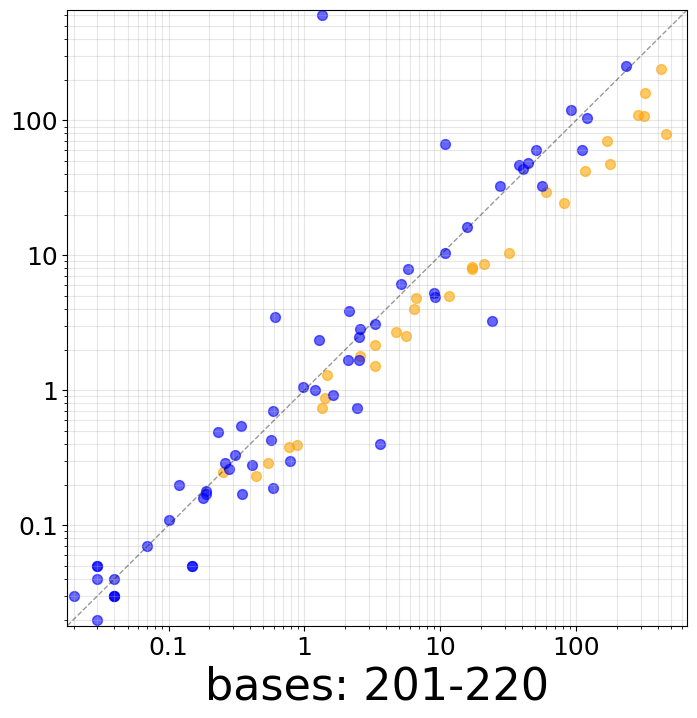

In [14]:
plot_scatter_solvers(
    table = table_201_220,
    solvers=['sym_201_220', 'par_201_220'],
    verdict_types=['sat', 'unsat', 'timeout'],
    labels={'sym_201_220': 'Sym', 'par_201_220': 'Par'},
    colors={'sym_201_220': 'blue', 'par_201_220': 'red'},  # ignored when using categories
    plot_name='scatter-201-220-existence.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'orange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 201-220"
)

# Benchmark: Split 2-21 - Universality problem 

### Instances

In [15]:
solvers_2 = ["sym_2_20","par_2_20"]

# Category: Modular

# par_2_20_divisibility =  pd.read_csv("CSV/divisibility/2-20/divisibility-2-par.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
# sym_2_20_divisibility =  pd.read_csv("CSV/divisibility/2-20/divisibility-2-sym.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

# print("Divisibility tables:", par_2_20_divisibility.shape[0], sym_2_20_divisibility.shape[0])

# divisibility_2_20 = pd.merge(par_2_20_divisibility, sym_2_20_divisibility, on="instance", how="outer")
# clean(divisibility_2_20, solvers_2)
# divisibility_2_20['category'] = "divisibility"

# Category: Random (Universality)

par_2_20_random_u =  pd.read_csv("CSV/random/2-20/random-2-par-u.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_random_u =  pd.read_csv("CSV/random/2-20/random-2-sym-u.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Random tables:", par_2_20_random_u.shape[0], sym_2_20_random_u.shape[0])

random_2_20_u = pd.merge(par_2_20_random_u, sym_2_20_random_u, on="instance", how="outer")
clean(random_2_20_u, solvers_2)
random_2_20_u['category'] = "random_u"

# Category: Mixed (Universality)

par_2_20_mixed_u =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-u.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_mixed_u =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-u.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Mixed tables:", par_2_20_mixed_u.shape[0], sym_2_20_mixed_u.shape[0])

mixed_2_20_u = pd.merge(par_2_20_mixed_u, sym_2_20_mixed_u, on="instance", how="outer")
clean(mixed_2_20_u, solvers_2)
mixed_2_20_u['category'] = "random_u"

# Combine Tables 

table_2_20 = pd.concat([# divisibility_2_20, 
                        random_2_20_u, 
                        mixed_2_20_u
                        ], ignore_index=True)
table_2_20

Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_2_20,time_par_2_20,verdict_sym_2_20,time_sym_2_20,category
0,ai-instances/random/random_01.smt2,unsat,0.03,unsat,0.03,random_u
1,ai-instances/random/random_02.smt2,unsat,0.10,unsat,0.05,random_u
2,ai-instances/random/random_03.smt2,sat,37.03,sat,287.92,random_u
3,ai-instances/random/random_04.smt2,unsat,3.13,unsat,2.61,random_u
4,ai-instances/random/random_05.smt2,unsat,6.95,unsat,1.67,random_u
5,ai-instances/random/random_06.smt2,unsat,2.38,unsat,1.23,random_u
6,ai-instances/random/random_07.smt2,unsat,9.15,unsat,6.13,random_u
7,ai-instances/random/random_08.smt2,sat,1.70,sat,1.17,random_u
8,ai-instances/random/random_09.smt2,sat,405.13,sat,274.24,random_u
9,ai-instances/random/random_10.smt2,sat,0.08,sat,0.10,random_u


### Scatter plot

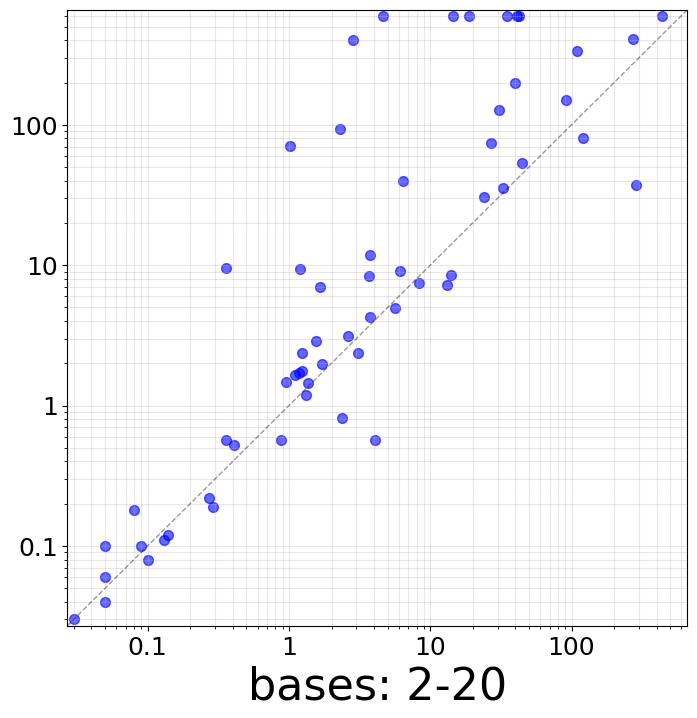

In [16]:
plot_scatter_solvers(
    table =  table_2_20,
    solvers= solvers_2,
    verdict_types= ['sat', 'unsat', 'timeout'],
    labels = {'sym_2_20': 'Sym', 'par_2_20': 'Par'},
    colors = {'sym_2_20': 'blue', 'par_2_20': 'red'},  # ignored when using categories
    plot_name = 'scatter-2-20-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'orange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 2-20"
)

# Benchmark: Split 21-200 - Universality problem 

### Instances

In [17]:
solvers_21 = ["sym_21_200","par_21_200"]

# Category: Divisibility

# par_21_200_divisibility =  pd.read_csv("CSV/modular/21-200/divisibility-21-par.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
# sym_21_200_divisibility =  pd.read_csv("CSV/modular/21-200/divisibility-21-sym.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

# print("Divisibility tables:", par_21_200_divisibility.shape[0], sym_21_200_divisibility.shape[0])

# divisibility_21_200 = pd.merge(par_21_200_divisibility, sym_21_200_divisibility, on="instance", how="outer")
# clean(divisibility_21_200, solvers_21)
# divisibility_21_200['category'] = "divisibility"

# Category: Random (Universality)

par_21_200_random_u =  pd.read_csv("CSV/random/21-200/random-21-par-u.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_random_u =  pd.read_csv("CSV/random/21-200/random-21-sym-u.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Random tables:", par_21_200_random_u.shape[0], sym_21_200_random_u.shape[0])

random_21_200_u = pd.merge(par_21_200_random_u, sym_21_200_random_u, on="instance", how="outer")
clean(random_21_200_u, solvers_21)
random_21_200_u['category'] = "random_u"

# Category: Mixed (Universality)

par_21_200_mixed_u =  pd.read_csv("CSV/mixed/21-200/mixed-21-par-u.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_mixed_u =  pd.read_csv("CSV/mixed/21-200/mixed-21-sym-u.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Mixed tables:", par_21_200_mixed_u.shape[0], sym_21_200_mixed_u.shape[0])

mixed_21_200_u = pd.merge(par_21_200_mixed_u, sym_21_200_mixed_u, on="instance", how="outer")
clean(mixed_21_200_u, solvers_21)
mixed_21_200_u['category'] = "random_u"

# Combine Tables 

table_21_200 = pd.concat([#divisibility_21_200, 
                          random_21_200_u, 
                          mixed_21_200_u
                         ], ignore_index=True)
table_21_200

Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_21_200,time_par_21_200,verdict_sym_21_200,time_sym_21_200,category
0,ai-instances/random/random_01.smt2,unsat,0.03,unsat,0.03,random_u
1,ai-instances/random/random_02.smt2,sat,0.41,sat,0.48,random_u
2,ai-instances/random/random_03.smt2,sat,9.09,sat,529.40,random_u
3,ai-instances/random/random_04.smt2,sat,2.18,sat,97.79,random_u
4,ai-instances/random/random_05.smt2,unsat,6.61,unsat,5.89,random_u
5,ai-instances/random/random_06.smt2,unsat,6.35,unsat,3.76,random_u
6,ai-instances/random/random_07.smt2,sat,2.78,sat,133.03,random_u
7,ai-instances/random/random_08.smt2,sat,18.95,sat,16.97,random_u
8,ai-instances/random/random_09.smt2,sat,31.51,timeout,600.00,random_u
9,ai-instances/random/random_10.smt2,sat,0.27,sat,0.74,random_u


### Scatter plot

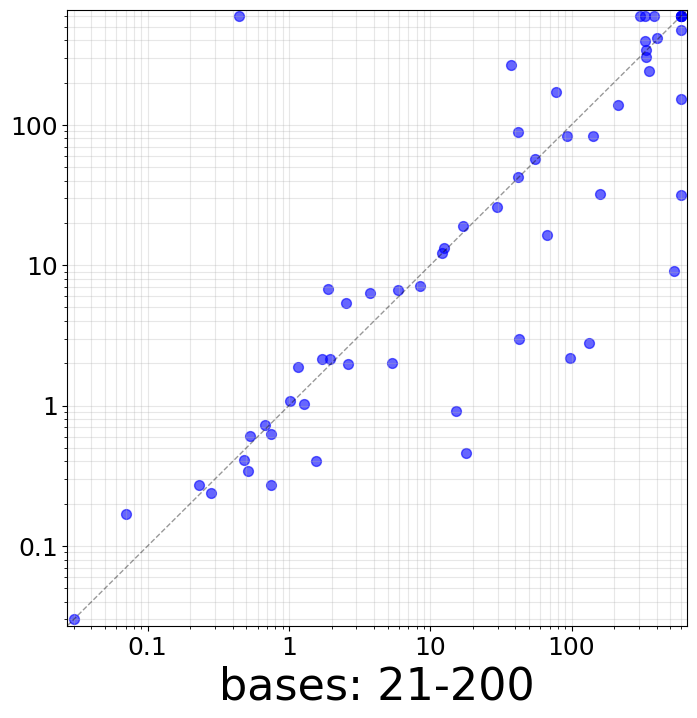

In [18]:
plot_scatter_solvers(
    table =  table_21_200,
    solvers= solvers_21,
    verdict_types= ['sat', 'unsat', 'timeout'],
    labels = {'sym_21_200': 'Sym', 'par_21_200': 'Par'},
    colors = {'sym_21_200': 'blue', 'par_21_200': 'red'},  # ignored when using categories
    plot_name = 'scatter-21-200-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'orange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 21-200"
)

# Benchmark: Split 201-220 - Universality problem 

### Instances

In [19]:
solvers_201 = ["par_201_220","sym_201_220"]

# Category: Divisibility

# par_201_220_divisibility =  pd.read_csv("CSV/modular/201-220/divisibility-201-par.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
# sym_201_220_divisibility =  pd.read_csv("CSV/modular/201-220/divisibility-201-sym.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

# print("Modular tables:", par_201_220_divisibility.shape[0], sym_201_220_divisibility.shape[0])

# divisibility_201_220 = pd.merge(par_201_220_divisibility, sym_201_220_divisibility, on="instance", how="outer")
# clean(divisibility_201_220, solvers_201)
# divisibility_201_220['category'] = "divisibility"

# Category: Random (Universality)

par_201_220_random_u =  pd.read_csv("CSV/random/201-220/random-201-par-u.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_random_u =  pd.read_csv("CSV/random/201-220/random-201-sym-u.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Random tables:", par_201_220_random_u.shape[0], sym_201_220_random_u.shape[0])

random_201_220_u = pd.merge(par_201_220_random_u, sym_201_220_random_u, on="instance", how="outer")
clean(random_201_220_u, solvers_201)
random_201_220_u['category'] = "random_u"

# Category: Mixed (Universality)

par_201_220_mixed_u =  pd.read_csv("CSV/mixed/201-220/mixed-201-par-u.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_mixed_u =  pd.read_csv("CSV/mixed/201-220/mixed-201-sym-u.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Mixed tables:", par_201_220_mixed_u.shape[0], sym_201_220_mixed_u.shape[0])

mixed_201_220_u = pd.merge(par_201_220_mixed_u, sym_201_220_mixed_u, on="instance", how="outer")
clean(mixed_201_220_u, solvers_201)
mixed_201_220_u['category'] = "random_u"

# Combine Tables 

table_201_220 = pd.concat([#divisibility_201_220, 
                            random_201_220_u, 
                            mixed_201_220_u
                            ], ignore_index=True)
table_201_220

Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_201_220,time_par_201_220,verdict_sym_201_220,time_sym_201_220,category
0,ai-instances/random/random_01.smt2,unsat,0.03,unsat,0.02,random_u
1,ai-instances/random/random_02.smt2,sat,0.07,sat,0.08,random_u
2,ai-instances/random/random_03.smt2,sat,3.77,sat,56.86,random_u
3,ai-instances/random/random_04.smt2,sat,0.38,sat,10.88,random_u
4,ai-instances/random/random_05.smt2,unsat,6.61,unsat,6.11,random_u
5,ai-instances/random/random_06.smt2,unsat,5.44,unsat,4.12,random_u
6,ai-instances/random/random_07.smt2,sat,0.45,sat,14.78,random_u
7,ai-instances/random/random_08.smt2,sat,1.97,sat,1.74,random_u
8,ai-instances/random/random_09.smt2,sat,17.14,sat,290.40,random_u
9,ai-instances/random/random_10.smt2,sat,0.07,sat,0.10,random_u


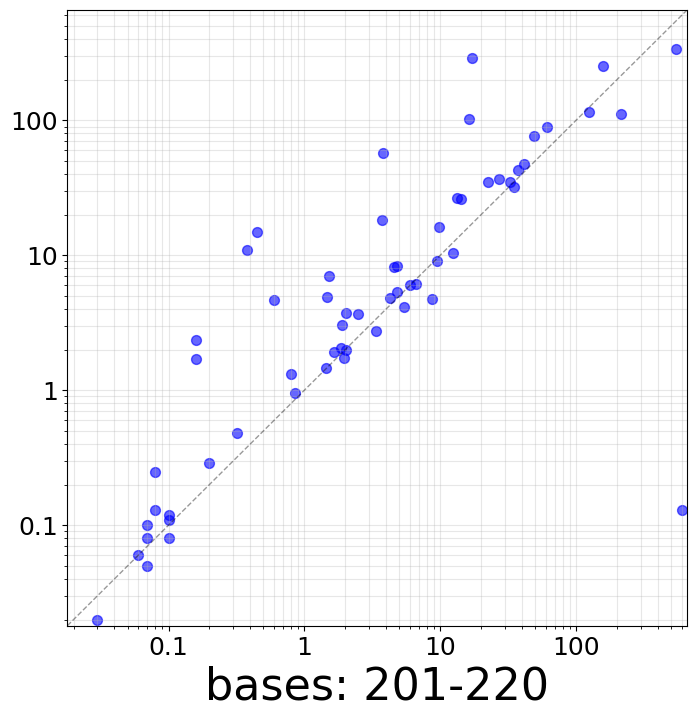

In [20]:
plot_scatter_solvers(
    table =  table_201_220,
    solvers= solvers_201,
    verdict_types= ['sat', 'unsat', 'timeout'],
    labels = {'sym_201_220': 'Sym', 'par_201_220': 'Par'},
    colors = {'sym_201_220': 'blue', 'par_201_220': 'red'},  # ignored when using categories
    plot_name = 'scatter-201-220-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'orange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 201-220"
)